In [13]:
# Shared project setup for imports and file locations
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

DATA_DIR = PROJECT_ROOT / 'data'
ARTIFACTS_DIR = PROJECT_ROOT / 'artifacts'
FIGURES_DIR = PROJECT_ROOT / 'figures'

from pdm_learn.preprocessing import densitymap
from pdm_learn.simulation import build_heatmap_dataset, build_metric_dataset, collect_simulated_pairs, perturb_pair


In [14]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from bisect import bisect_left

In [15]:
positive = pd.read_csv(DATA_DIR / 'simulated' / 'positive.csv').reset_index(drop=True)

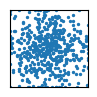

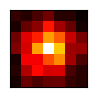

In [ ]:
from scipy.stats import pearsonr, spearmanr
from sklearn.feature_selection import mutual_info_regression

SIM_CENTERS = np.linspace(-2, 2, 7)
EPSILON_STD = 3.0
NEGATIVE_REPEATS = 200
HEATMAP_SIGMA = 0.1
RANDOM_SEED = 42

def compute_mi(x, y):
    return mutual_info_regression(x.reshape(-1, 1), y, discrete_features=False)[0]

def bicor(x, y, c=9.0):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = (~np.isnan(x)) & (~np.isnan(y))
    x = x[mask]
    y = y[mask]
    if len(x) < 3:
        return np.nan
    x_med = np.median(x)
    y_med = np.median(y)
    x_mad = np.median(np.abs(x - x_med))
    y_mad = np.median(np.abs(y - y_med))
    if x_mad == 0 or y_mad == 0:
        return np.nan
    ux = (x - x_med) / (c * x_mad)
    uy = (y - y_med) / (c * y_mad)
    wx = (1 - ux**2)**2
    wy = (1 - uy**2)**2
    wx[np.abs(ux) >= 1] = 0
    wy[np.abs(uy) >= 1] = 0
    xw = (x - x_med) * wx
    yw = (y - y_med) * wy
    numerator = np.sum(xw * yw)
    denominator = np.sqrt(np.sum(xw**2) * np.sum(yw**2))
    return numerator / denominator if denominator != 0 else np.nan

rng = np.random.default_rng(RANDOM_SEED)
preview_x = positive.iloc[60].to_numpy()
preview_y = positive.iloc[61].to_numpy()
preview_x, preview_y = perturb_pair(preview_x, preview_y, EPSILON_STD, centers=SIM_CENTERS, rng=rng)

plt.figure(figsize=(1, 1))
plt.scatter(preview_x, preview_y, s=2)
plt.xlim(min(SIM_CENTERS), max(SIM_CENTERS))
plt.ylim(min(SIM_CENTERS), max(SIM_CENTERS))
plt.xticks([])
plt.yticks([])
plt.show()

preview_map = densitymap(preview_x, preview_y, SIM_CENTERS, SIM_CENTERS, sigma=HEATMAP_SIGMA)[::-1]
plt.figure(figsize=(1, 1))
plt.imshow(preview_map, cmap='hot', interpolation='nearest')
plt.xticks([])
plt.yticks([])
plt.show()


In [5]:
positive_pairs = collect_simulated_pairs(
    positive,
    repeats=1,
    epsilon_std=EPSILON_STD,
    centers=SIM_CENTERS,
    rng=np.random.default_rng(RANDOM_SEED),
)
negative_pairs = collect_simulated_pairs(
    positive,
    repeats=NEGATIVE_REPEATS,
    epsilon_std=EPSILON_STD,
    shuffle_y=True,
    centers=SIM_CENTERS,
    rng=np.random.default_rng(RANDOM_SEED + 1),
)

heatmap_positive = build_heatmap_dataset(
    positive,
    densitymap,
    centers=SIM_CENTERS,
    repeats=1,
    epsilon_std=EPSILON_STD,
    sigma=HEATMAP_SIGMA,
    simulated_pairs=positive_pairs,
)
heatmap_positive.to_csv(DATA_DIR / 'simulated' / 'positive_heatmap.csv', index=False)

heatmap_negative = build_heatmap_dataset(
    positive,
    densitymap,
    centers=SIM_CENTERS,
    repeats=NEGATIVE_REPEATS,
    epsilon_std=EPSILON_STD,
    sigma=HEATMAP_SIGMA,
    shuffle_y=True,
    simulated_pairs=negative_pairs,
)
heatmap_negative.to_csv(DATA_DIR / 'simulated' / 'negative_heatmap.csv', index=False)

heatmap_positive.head()


,0,1,2,3,4,5,6,7,8,9,...,39,40,41,42,43,44,45,46,47,48
0,-3.798323,-3.502423,-3.541819,-3.372059,-3.247646,-3.639092,-3.712960,-3.755265,-3.244521,-2.894870,...,-3.209036,-3.369766,-3.797620,-3.635296,-3.650589,-3.515375,-3.340049,-3.656909,-3.692529,-3.891458
1,-3.545791,-3.481126,-3.314017,-3.425486,-3.405439,-3.505085,-3.699569,-3.666005,-3.337543,-2.991665,...,-3.197285,-3.597314,-3.688189,-3.798320,-3.691179,-3.510834,-3.561766,-3.485624,-3.822162,-3.891809
2,-3.712835,-3.762084,-3.588046,-3.277699,-3.200857,-3.812465,-3.784064,-3.699580,-3.496886,-3.361476,...,-3.068680,-3.442053,-3.633158,-3.557642,-3.728656,-3.412966,-3.480202,-3.526472,-3.562874,-3.692513
3,-3.798331,-3.638073,-3.394338,-3.346797,-3.563571,-3.792900,-3.798330,-3.735542,-3.194967,-3.171449,...,-3.246087,-3.436687,-3.581470,-3.712837,-3.561077,-3.457405,-3.529256,-3.369990,-3.877961,-3.870154
4,-3.798738,-3.551920,-3.572680,-3.371020,-3.657594,-3.386019,-3.884998,-3.648515,-3.351634,-3.055931,...,-3.043812,-3.479893,-3.715071,-3.891820,-3.856085,-3.553596,-3.344581,-3.445091,-3.797626,-3.798330


In [6]:
metric_specs = {
    'pearson': lambda x, y: pearsonr(x, y)[0],
    'spearman': lambda x, y: spearmanr(x, y)[0],
    'mi': compute_mi,
    'bicor': bicor,
}

for offset, (name, metric_fn) in enumerate(metric_specs.items(), start=10):
    positive_df = build_metric_dataset(
        positive,
        metric_fn,
        repeats=1,
        epsilon_std=EPSILON_STD,
        centers=SIM_CENTERS,
        column_name=name.upper() if name != 'bicor' else 'BiCor',
        simulated_pairs=positive_pairs,
    )
    positive_df.to_csv(DATA_DIR / 'simulated' / f'positive_{name}.csv', index=False)

    negative_df = build_metric_dataset(
        positive,
        metric_fn,
        repeats=NEGATIVE_REPEATS,
        epsilon_std=EPSILON_STD,
        shuffle_y=True,
        centers=SIM_CENTERS,
        column_name=name.upper() if name != 'bicor' else 'BiCor',
        simulated_pairs=negative_pairs,
    )
    negative_df.to_csv(DATA_DIR / 'simulated' / f'negative_{name}.csv', index=False)

{name: pd.read_csv(DATA_DIR / 'simulated' / f'positive_{name}.csv').head() for name in metric_specs}


{'pearson':     PEARSON
 0  0.008812
 1 -0.015591
 2 -0.029550
 3 -0.028495
 4 -0.017607,
 'spearman':    SPEARMAN
 0  0.026822
 1 -0.016407
 2 -0.026925
 3 -0.027710
 4 -0.014368,
 'mi':          MI
 0  0.011590
 1  0.000000
 2  0.000000
 3  0.052898
 4  0.000000,
 'bicor':       BiCor
 0  0.020940
 1 -0.016191
 2 -0.028086
 3 -0.027735
 4 -0.017045}

In [7]:
pd.read_csv(DATA_DIR / 'simulated' / 'positive_pearson.csv').head()


,PEARSON
0,0.008812
1,-0.015591
2,-0.029550
3,-0.028495
4,-0.017607


In [8]:
pd.read_csv(DATA_DIR / 'simulated' / 'positive_spearman.csv').head()


,SPEARMAN
0,0.026822
1,-0.016407
2,-0.026925
3,-0.027710
4,-0.014368


In [9]:
pd.read_csv(DATA_DIR / 'simulated' / 'positive_mi.csv').head()


,MI
0,0.011590
1,0.000000
2,0.000000
3,0.052898
4,0.000000


In [10]:
pd.read_csv(DATA_DIR / 'simulated' / 'positive_bicor.csv').head()


,BiCor
0,0.020940
1,-0.016191
2,-0.028086
3,-0.027735
4,-0.017045


In [11]:
pd.read_csv(DATA_DIR / 'simulated' / 'negative_heatmap.csv').head()


,0,1,2,3,4,5,6,7,8,9,...,39,40,41,42,43,44,45,46,47,48
0,-3.712791,-3.366313,-3.425113,-3.569859,-3.541432,-3.472377,-3.690457,-3.738083,-3.375133,-3.214124,...,-3.139464,-3.652925,-3.649479,-3.715874,-3.794803,-3.570408,-3.255134,-3.370545,-3.634299,-3.880384
1,-3.637010,-3.783238,-3.321959,-3.334015,-3.706539,-3.715804,-3.746484,-3.828268,-3.504279,-3.213659,...,-3.124456,-3.436642,-3.500954,-3.760254,-3.658621,-3.697332,-3.445462,-3.315573,-3.798327,-3.711215
2,-3.727673,-3.533989,-3.666990,-3.572340,-3.573065,-3.673032,-3.798330,-3.856216,-3.469580,-2.811576,...,-3.411167,-3.314208,-3.693208,-3.798091,-3.594361,-3.707703,-3.448758,-3.351098,-3.313254,-3.891310
3,-3.715370,-3.721651,-3.292813,-3.273749,-3.608795,-3.739078,-3.714006,-3.712795,-3.470425,-3.201377,...,-2.959041,-3.314571,-3.891685,-3.685730,-3.831305,-3.666917,-3.476920,-3.318577,-3.568193,-3.891820
4,-3.792402,-3.807914,-3.432057,-3.426878,-3.700791,-3.571783,-3.634070,-3.495673,-3.527245,-2.994121,...,-3.032502,-3.429110,-3.691433,-3.798330,-3.793855,-3.169209,-3.484956,-3.356593,-3.635103,-3.818351


In [12]:
plt.imshow(positive_df.iloc[100, :].to_numpy().reshape(7,7), cmap='hot', interpolation='nearest')
plt.show()

IndexError: single positional indexer is out-of-bounds